[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Data-Crew/transport-networks-lab/blob/main/Notebooks/accesibilidad/Problemas%20de%20accesibilidad%20I%20-%20Pandana.ipynb)


#  Grafos y redes de transporte. Accesibilidad con `Pandana`



[Pandana](!https://github.com/UDST/pandana?tab=readme-ov-file#pandana) es una librería que facilita la estimación de métricas de accesibilidad y movilidad en redes de transporte.

In [1]:
%%capture

# https://github.com/UDST/pandana
!pip install pandana

# https://github.com/UDST/osmnet
!pip install osmnet

In [2]:
from google.colab import drive
drive.mount("/drive/")

Mounted at /drive/


In [3]:
import pandas as pd

import pandana
print(pandana.__version__)

0.7


In [4]:
from pandana.loaders import osm

import warnings
warnings.filterwarnings('ignore')

### 1. Creo una red vial y determino puntos de interés.

In [5]:
# para mas detalle

# ver: https://udst.github.io/osmnet/osmnet.html
# La clase Network: https://github.com/UDST/pandana/blob/dev/pandana/network.py

bbox = [-34.59735464,-58.61822155,-34.49018807,-58.50991202]
network = osm.pdna_network_from_bbox(bbox[0],bbox[1],bbox[2],bbox[3])

INFO:osmnet:Requesting network data within bounding box from Overpass API in 1 request(s)
INFO:osmnet:Posting to http://www.overpass-api.de/api/interpreter with timeout=180, "{'data': '[out:json][timeout:180];(way["highway"]["highway"!~"motor|proposed|construction|abandoned|platform|raceway"]["foot"!~"no"]["pedestrians"!~"no"](-34.59735464,-58.61822155,-34.49018807,-58.50991202);>;);out;'}"


Requesting network data within bounding box from Overpass API in 1 request(s)
Posting to http://www.overpass-api.de/api/interpreter with timeout=180, "{'data': '[out:json][timeout:180];(way["highway"]["highway"!~"motor|proposed|construction|abandoned|platform|raceway"]["foot"!~"no"]["pedestrians"!~"no"](-34.59735464,-58.61822155,-34.49018807,-58.50991202);>;);out;'}"


INFO:osmnet:Downloaded 6,027.9KB from www.overpass-api.de in 1.19 seconds
INFO:osmnet:Downloaded OSM network data within bounding box from Overpass API in 1 request(s) and 1.29 seconds


Downloaded 6,027.9KB from www.overpass-api.de in 1.19 seconds
Downloaded OSM network data within bounding box from Overpass API in 1 request(s) and 1.29 seconds


INFO:osmnet:Returning OSM data with 32,634 nodes and 10,690 ways...


Returning OSM data with 32,634 nodes and 10,690 ways...


INFO:osmnet:Edge node pairs completed. Took 10.77 seconds
INFO:osmnet:Returning processed graph with 15,820 nodes and 25,837 edges...
INFO:osmnet:Completed OSM data download and Pandana node and edge table creation in 12.78 seconds


Edge node pairs completed. Took 10.77 seconds
Returning processed graph with 15,820 nodes and 25,837 edges...
Completed OSM data download and Pandana node and edge table creation in 12.78 seconds


In [6]:
help(network)

Help on Network in module pandana.network object:

class Network(builtins.object)
 |  Network(node_x, node_y, edge_from, edge_to, edge_weights, twoway=True)
 |  
 |  Create the transportation network in the city.  Typical data would be
 |  distance based from OpenStreetMap or travel time from GTFS transit data.
 |  
 |  Parameters
 |  ----------
 |  node_x : pandas.Series, float
 |      Defines the x attribute for nodes in the network (e.g. longitude)
 |  node_y : pandas.Series, float
 |      Defines the y attribute for nodes in the network (e.g. latitude)
 |      This param and the one above should have the *same* index which
 |      should be the node_ids that are referred to in the edges below.
 |  edge_from : pandas.Series, int
 |      Defines the node ID that begins an edge - should refer to the index
 |      of the two series objects above
 |  edge_to : pandas.Series, int
 |      Defines the node ID that ends an edge - should refer to the index
 |      of the two series objects a

In [7]:
# Metodos
methods = [attr for attr in dir(network) if callable(getattr(network, attr))]
print("Methods:", methods)

# Atributos
attributes = [attr for attr in dir(network) if not callable(getattr(network, attr)) and not attr.startswith('__')]
print("Attributes:", attributes)


Methods: ['__class__', '__delattr__', '__dir__', '__eq__', '__format__', '__ge__', '__getattribute__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '_imp_name_to_num', '_node_indexes', 'aggregate', 'from_hdf5', 'get_node_ids', 'init_pois', 'low_connectivity_nodes', 'nearest_pois', 'nodes_in_range', 'plot', 'precompute', 'save_hdf5', 'set', 'set_pois', 'shortest_path', 'shortest_path_length', 'shortest_path_lengths', 'shortest_paths']
Attributes: ['_twoway', 'aggregations', 'bbox', 'decays', 'edges_df', 'impedance_names', 'kdtree', 'net', 'node_ids', 'node_idx', 'nodes_df', 'poi_category_indexes', 'poi_category_names', 'variable_names']


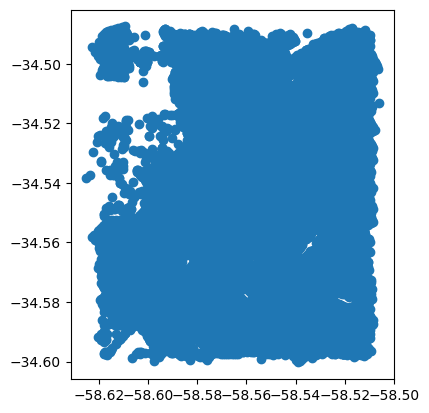

In [8]:
import geopandas as gpd
from shapely.geometry import Point

nodes_df = network.nodes_df.copy()
nodes_df['geometry'] = nodes_df.apply(lambda row: Point(row['x'], row['y']), axis=1)

gdf = gpd.GeoDataFrame(nodes_df, geometry='geometry', crs="EPSG:4326")

gdf.plot();


In [9]:
target_tags = ['"amenity"~"school"', '"leisure"~"park"', '"amenity"~"restaurant|bar"']

In [10]:
# creo un objeto para guardar la consulta de los resultados de mi query
tpois = osm.node_query(bbox[0],bbox[1],bbox[2],bbox[3],
                       tags=target_tags[0])

In [12]:
# ahora, puedo asociarlo a mi red vial
network.set_pois(category = 'tpois',
                 maxdist = 1000,
                 maxitems = 3,
                 x_col = tpois.lon,
                 y_col = tpois.lat)

In [13]:
# y encontrar los n puntos mas cercanos en un radio de distancia x a los nodos de la red
results = network.nearest_pois(distance = 1000,
                               category = 'tpois',
                               num_pois = 3,
                               include_poi_ids = True)
results.head()

,1,2,3,poi1,poi2,poi3
id,,,,,,
29647104,0.000000,731.804016,731.804016,1.028549e+10,1.028549e+10,1.028549e+10
29652262,88.888000,200.731003,200.731003,1.028549e+10,2.189023e+09,1.028549e+10
30491461,276.786011,449.404999,513.127991,5.080345e+09,1.028549e+10,1.028549e+10
32724528,333.746002,333.746002,333.746002,1.028549e+10,1.028549e+10,1.028549e+10
32724531,178.391998,178.391998,178.391998,8.132941e+09,1.028549e+10,1.028549e+10


### 2. Estimo métricas de accesibilidad

In [14]:
# ahora, me quedo con el nodo mas cercano de cada punto de interes
tpois_nodes = network.get_node_ids(tpois.lon, tpois.lat)

In [15]:
tpois_nodes

,node_id
id,
573459312,597220544
999325984,597204236
1010894202,241930150
1100525643,290420952
1122555328,1409304801
...,...
10288955867,6369245914
10288955868,332571504
10288955869,332571504


In [16]:
# lo asocio a mi red nuevamente
network.set(tpois_nodes,
            name = 'tpois')

# y ya puedo hacer la agregacion que quiera
accessibility = network.aggregate(distance = 500,
                                  type = 'count',
                                  name = 'tpois')
accessibility.describe()

,0
count,15820.000000
mean,1.097029
std,1.856405
min,0.000000
25%,0.000000
50%,0.000000
75%,2.000000
max,19.000000


In [20]:
accessibility

,0
id,
29647104,1.0
29652262,10.0
30491461,2.0
32724528,8.0
32724531,3.0
...,...
12156397746,0.0
12156397747,0.0
12156397748,0.0


In [17]:
import matplotlib
from matplotlib import pyplot as plt

print(matplotlib.__version__)

3.7.1


In [18]:
import geopandas as gpd
polyg = gpd.read_file('/drive/MyDrive/Técnicas y Análisis de datos del Transporte/Colab Notebooks/accesibilidad/Polyg_371.zip')

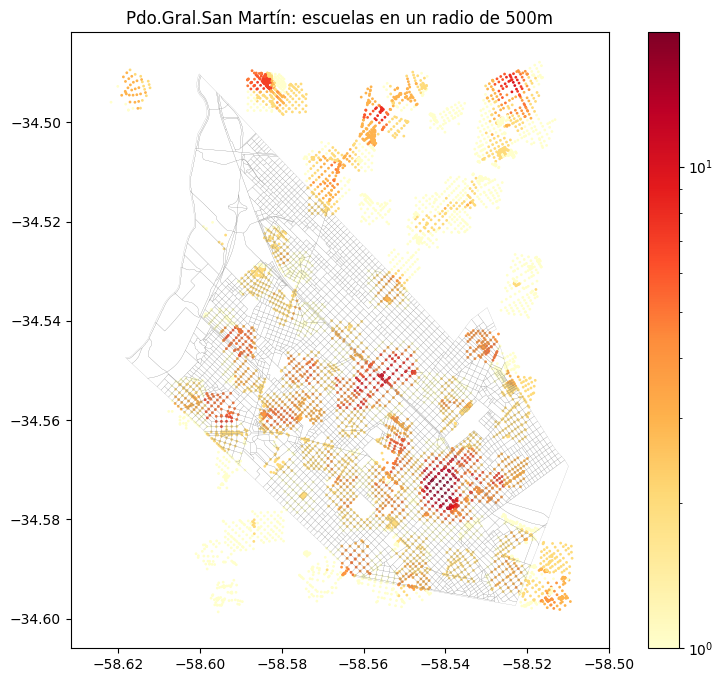

In [22]:
# para ver cantidad de escuelas (ojo la escala logaritmica)
fig, ax = plt.subplots(figsize=(10,8))

plt.title('Pdo.Gral.San Martín: escuelas en un radio de 500m')
plt.scatter(network.nodes_df.x, network.nodes_df.y,
            c=accessibility, s=1, cmap='YlOrRd',
            norm=matplotlib.colors.LogNorm()
            )
cb = plt.colorbar()
polyg.geometry.boundary.to_crs(4326).plot(ax=ax, linewidth=0.1, color='grey')
plt.show()

Para aquellos que no estén muy familiarizados con la lectura de escalas logarítmicas, recomendamos la [siguiente](https://blog.datawrapper.de/weeklychart-logscale2/) lectura. Esencialmente, el uso de la escala logaritmica nos permite distinguir con mayor claridad los nodos con al menos una escuela de aquellos con ninguna.

In [23]:
results

,1,2,3,poi1,poi2,poi3
id,,,,,,
29647104,0.000000,731.804016,731.804016,1.028549e+10,1.028549e+10,1.028549e+10
29652262,88.888000,200.731003,200.731003,1.028549e+10,2.189023e+09,1.028549e+10
30491461,276.786011,449.404999,513.127991,5.080345e+09,1.028549e+10,1.028549e+10
32724528,333.746002,333.746002,333.746002,1.028549e+10,1.028549e+10,1.028549e+10
32724531,178.391998,178.391998,178.391998,8.132941e+09,1.028549e+10,1.028549e+10
...,...,...,...,...,...,...
12156397746,546.900024,580.661011,580.661011,3.018465e+09,3.018465e+09,1.028891e+10
12156397747,545.304993,582.255981,582.255981,3.018465e+09,3.018465e+09,1.028891e+10
12156397748,529.814026,597.747009,597.747009,3.018465e+09,3.018465e+09,1.028891e+10


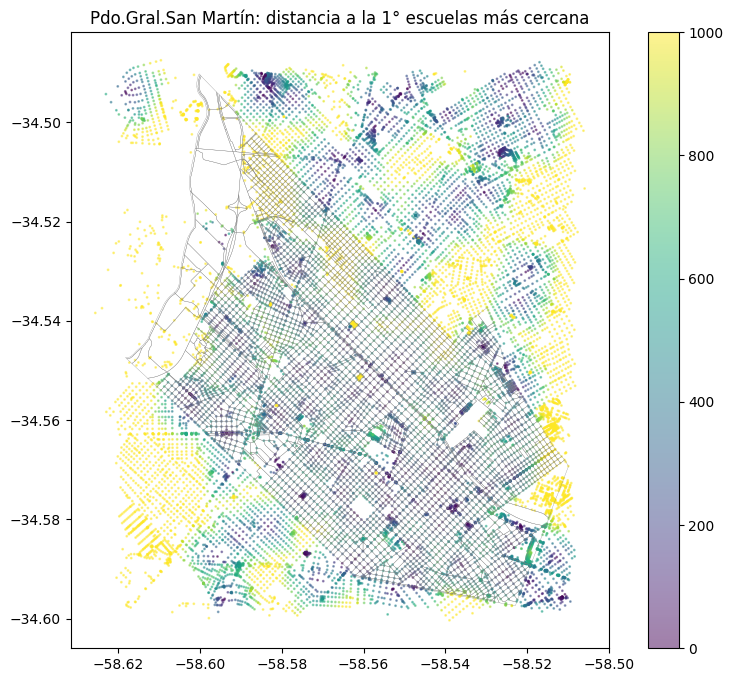

In [24]:
# ... o distancia a la escuela mas cercana
fig, ax = plt.subplots(figsize=(10,8))

plt.title('Pdo.Gral.San Martín: distancia a la 1° escuelas más cercana')
plt.scatter(network.nodes_df.x, network.nodes_df.y,
            c=results[1], s=1, cmap='viridis',alpha=0.5
            )
cb = plt.colorbar()
polyg.geometry.boundary.to_crs(4326).plot(ax=ax, linewidth=0.2, color='grey')
plt.show()

### 3. Creo una referencia de demanda para los puntos de interés

In [25]:
path = '/drive/MyDrive/Técnicas y Análisis de datos del Transporte/Colab Notebooks/accesibilidad/radios_rmba.geojson'
rmba = gpd.read_file(path)

In [26]:
# ponemos estos resultados, en contexto poblacional
smartin = rmba.loc[rmba.link.apply(lambda x: x[:5]=='06371')].copy().to_crs(4326)

In [27]:
# creamos una referencia x/y al centroide del radio
smartin['x'] = smartin.geometry.centroid.x
smartin['y'] = smartin.geometry.centroid.y

In [28]:
# y le asignamos el nodo mas cercano al centroide del poligono
smartin['node_id'] = network.get_node_ids(smartin['x'],smartin['y'])

In [29]:
smartin.columns

Index(['link', 'varon', 'mujer', 'personas', 'hogares', 'viv_part',
       'viv_part_hab', 'densidad', 'geometry', 'x', 'y', 'node_id'],
      dtype='object')

In [30]:
# para determinar ahora, la cantidad de hogares en un radio x a los nodos de la red
network.set(smartin.node_id,
            variable=smartin['hogares'])
dist = 1
agg_dist = dist*1000
results2 = network.aggregate(agg_dist, type='sum', decay='linear')

In [31]:
results2.describe()

,0
count,15820.000000
mean,715.492835
std,838.401428
min,0.000000
25%,0.000000
50%,201.767212
75%,1465.770354
max,3133.519399


In [32]:
smartin['hogares_1km'] = smartin['node_id'].map(results2)

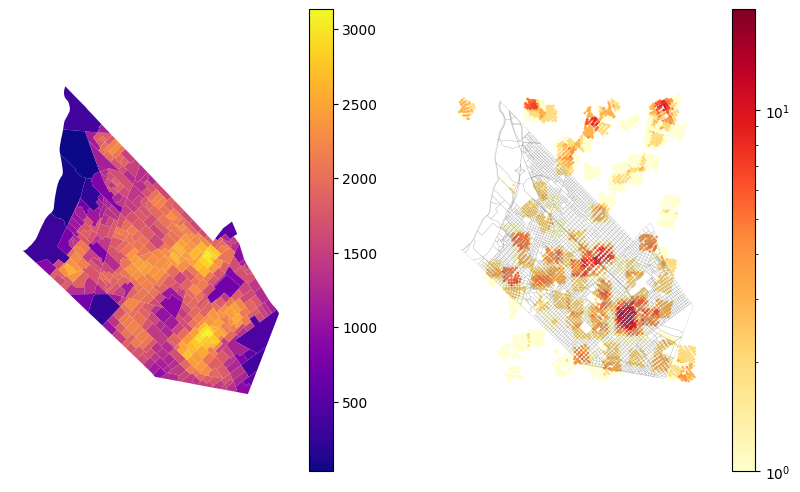

In [33]:
# y ahora si, vemos cómo se distribuyen tanto escuelas como población
f = plt.figure(figsize=(10,6))
ax1 = f.add_subplot(1,2,1)
ax2 = f.add_subplot(1,2,2)

c = smartin.plot(ax=ax1, column='hogares_1km', cmap='plasma',
                 legend=True)

s = ax2.scatter(network.nodes_df.x, network.nodes_df.y,
                c=accessibility, s=1, cmap='YlOrRd',
                norm=matplotlib.colors.LogNorm(),
                )
cbII = plt.colorbar(s)
polyg.geometry.boundary.to_crs(4326).plot(ax=ax2, linewidth=0.1, color='grey')

ax1.set_axis_off()
ax2.set_axis_off();